# Warehouse Classification using Random Forest
Migrated from GEE `smileRandomForest` to scikit-learn

In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from glob import glob
import os
import pandas as pd

## 1. Load Raster

In [2]:
# tif_files = sorted(glob('../warehouse_od/data/satellite/pl_satellite/full_satellite/indianapolis.tif'))
# print(f'Found {len(tif_files)} band(s): {tif_files}')

# with rasterio.open(tif_files[0]) as src:
#     raster_crs = src.crs
#     raster_transform = src.transform
#     raster_shape = (src.height, src.width)

#     # If multi-band in single file
#     if src.count >= 8:
#         raster = src.read()  # (bands, rows, cols)
#     else:
#         # Stack individual band files
#         bands = []
#         for f in tif_files:
#             with rasterio.open(f) as b:
#                 bands.append(b.read(1))
#         raster = np.stack(bands)  # (bands, rows, cols)

#     nodata = src.nodata

# print(f'Raster shape: {raster.shape}')  # expect (8, H, W)
# print(f'CRS: {raster_crs}')

tif_files = sorted(glob('../warehouse_od/data/satellite/pl_satellite/full_satellite/indianapolis.tif'))
print(f'Found {len(tif_files)} band(s): {tif_files}')

with rasterio.open(tif_files[0]) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_shape = (src.height, src.width)

    # If multi-band in single file
    if src.count >= 8:
        raster = src.read()  # (bands, rows, cols)
    else:
        # Stack individual band files
        bands = []
        for f in tif_files:
            with rasterio.open(f) as b:
                bands.append(b.read(1))
        raster = np.stack(bands)  # (bands, rows, cols)

    nodata = src.nodata

print(f'Raster shape: {raster.shape}')  # expect (8, H, W)
print(f'CRS: {raster_crs}')

Found 1 band(s): ['../warehouse_od/data/satellite/pl_satellite/full_satellite/indianapolis.tif']
Raster shape: (8, 21174, 29694)
CRS: EPSG:32616


## (Optional) Apply AOI Masks

In [3]:
AOI_PATH = 'aoi.geojson'

aoi_gdf = gpd.read_file(AOI_PATH).to_crs(raster_crs)
aoi_geoms = aoi_gdf.geometry.values

with rasterio.open(tif_files[0]) as src:
    raster_masked, raster_transform = mask(src, aoi_geoms, crop=True, nodata=nodata if nodata is not None else 0)

# Re-stack all bands using the cropped transform/shape
if raster_masked.shape[0] >= 8:
    raster = raster_masked
else:
    cropped_bands = []
    for f in tif_files:
        with rasterio.open(f) as b:
            band_cropped, _ = mask(b, aoi_geoms, crop=True, nodata=nodata if nodata is not None else 0)
            cropped_bands.append(band_cropped[0])
    raster = np.stack(cropped_bands)

raster_shape = (raster.shape[1], raster.shape[2])
print(f'AOI applied. Cropped raster shape: {raster.shape}')

AOI applied. Cropped raster shape: (8, 20111, 23138)


## 2. Load & Reproject Training Polygons

In [18]:
gdf = gpd.read_file('new_landuse_data/warehouse_indie.shp')
gdf['type']

0      warehouse
1      warehouse
2      warehouse
3      warehouse
4      warehouse
         ...    
292         road
293         road
294         road
295         road
296         road
Name: type, Length: 297, dtype: object

In [19]:
shp_files = sorted(glob('new_landuse_data/*.shp'))
print(f'Found GeoJSONs: {shp_files}')

gdfs = []
for f in shp_files:
    gdf = gpd.read_file(f)
    # Assign label based on filename
    label = gdf['type'].str.contains('warehouse').astype(int)
    gdf['label'] = label
    gdfs.append(gdf)

training_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
training_gdf = training_gdf.to_crs(raster_crs)

print(training_gdf['label'].value_counts())

Found GeoJSONs: ['new_landuse_data/warehouse_indie.shp']
label
0    227
1     70
Name: count, dtype: int64


In [6]:
geojson_files = sorted(glob('../warehouse_od/data/warehouse/*.geojson'))
print(f'Found GeoJSONs: {geojson_files}')

gdfs = []
for f in geojson_files:
    gdf = gpd.read_file(f)
    # Assign label based on filename
    label = 1 if 'warehouse' in os.path.basename(f).lower() and 'non' not in os.path.basename(f).lower() else 0
    gdf['label'] = label
    gdfs.append(gdf)

training_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
training_gdf = training_gdf.to_crs(raster_crs)

print(training_gdf['label'].value_counts())

Found GeoJSONs: ['../warehouse_od/data/warehouse/indie_nonwarehouse_aoi1.geojson', '../warehouse_od/data/warehouse/indie_nonwarehouse_aoi_2.geojson', '../warehouse_od/data/warehouse/indie_nonwarehouse_aoi_7.geojson', '../warehouse_od/data/warehouse/indie_vegetation_aoi_2.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_1.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_2.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_3.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_4.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_5.geojson', '../warehouse_od/data/warehouse/warehouse_indie_aoi_6.geojson']
label
0    119
1    107
Name: count, dtype: int64


## 3. Rasterize Training Polygons

In [20]:
shapes = ((geom, val) for geom, val in zip(training_gdf.geometry, training_gdf['label']))

label_mask = rasterize(
    shapes=shapes,
    out_shape=raster_shape,
    transform=raster_transform,
    fill=255,          # 255 = no training data
    dtype='uint8'
)

print(f'Label mask unique values: {np.unique(label_mask)}')
# Expected: 0 (nonwarehouse), 1 (warehouse), 255 (unlabeled)

Label mask unique values: [  0   1 255]


## 3.5 Create Brightness Index and NDVI

In [21]:
raster_float = raster.astype(np.float32)

# Band indices (0-based): Band 6 = Red (idx 5), Band 8 = NIR (idx 7)
red = raster_float[5]
nir = raster_float[7]

# NDVI
denom = nir + red
ndvi = np.where(denom == 0, 0.0, (nir - red) / denom)  # (H, W)

# Brightness Index: sqrt of sum of squares across all 8 original bands
bi = np.sqrt(np.sum(raster_float ** 2, axis=0))  # (H, W)

# Append as new bands -> shape becomes (10, H, W)
raster = np.concatenate([
    raster_float,
    ndvi[np.newaxis, :, :],
    bi[np.newaxis, :, :]
], axis=0)

BAND_NAMES = [
    'Coastal Blue (443)', 'Blue (490)', 'Green I (531)', 'Green (565)',
    'Yellow (610)', 'Red (665)', 'Red Edge (705)', 'NIR (865)',
    'NDVI', 'Brightness Index'
]

print(f'Raster shape after adding indices: {raster.shape}')  # expect (10, H, W)

Raster shape after adding indices: (12, 20111, 23138)


## 4. Extract Pixel Samples

In [22]:
# Reshape raster to (H*W, bands)
n_bands, n_rows, n_cols = raster.shape
X_all = raster.reshape(n_bands, -1).T  # (pixels, bands)
y_all = label_mask.ravel()             # (pixels,)

# Keep only labeled pixels
labeled_mask = y_all != 255
X = X_all[labeled_mask]
y = y_all[labeled_mask]

# Optionally remove nodata pixels
if nodata is not None:
    valid = ~np.any(X == nodata, axis=1)
    X, y = X[valid], y[valid]

print(f'Training samples: {X.shape}')  # (n_samples, 8)
print(f'Class distribution: {np.bincount(y)}')

Training samples: (169, 12)
Class distribution: [99 70]


## 5. Train / Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Train Random Forest

In [24]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt', # equivalent to GEE variablesPerSplit
    min_samples_leaf=1, # equivalent to GEE minLeafPopulation
    random_state=420,
    n_jobs=-1
)

clf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 7. Evaluate

              precision    recall  f1-score   support

nonwarehouse       0.95      0.90      0.92        20
   warehouse       0.87      0.93      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.91      0.91      0.91        34



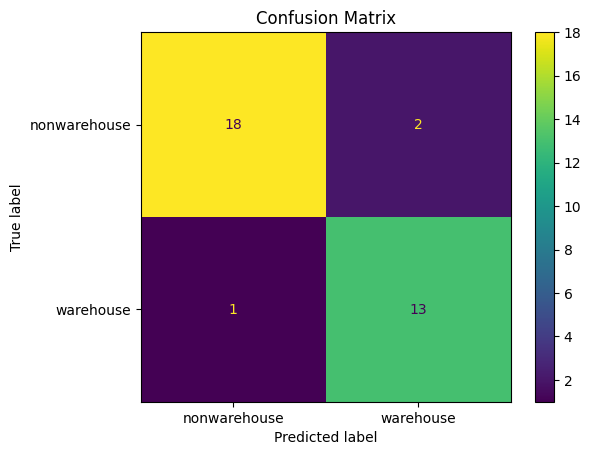

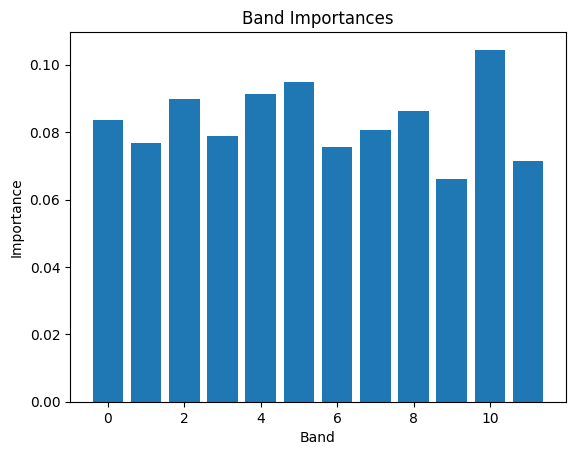

In [25]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['nonwarehouse', 'warehouse']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['nonwarehouse', 'warehouse'])
plt.title('Confusion Matrix')
plt.show()

# Feature importances
importances = clf.feature_importances_
plt.bar(range(n_bands), importances)
plt.xlabel('Band')
plt.ylabel('Importance')
plt.title('Band Importances')
plt.show()

## 8. Predict on Full Image

In [26]:
# Handle nodata pixels
if nodata is not None:
    valid_pixels = ~np.any(X_all == nodata, axis=1)
else:
    valid_pixels = np.ones(X_all.shape[0], dtype=bool)

prediction_flat = np.zeros(X_all.shape[0], dtype='uint8')
prediction_flat[valid_pixels] = clf.predict(X_all[valid_pixels])

prediction_map = prediction_flat.reshape(n_rows, n_cols)

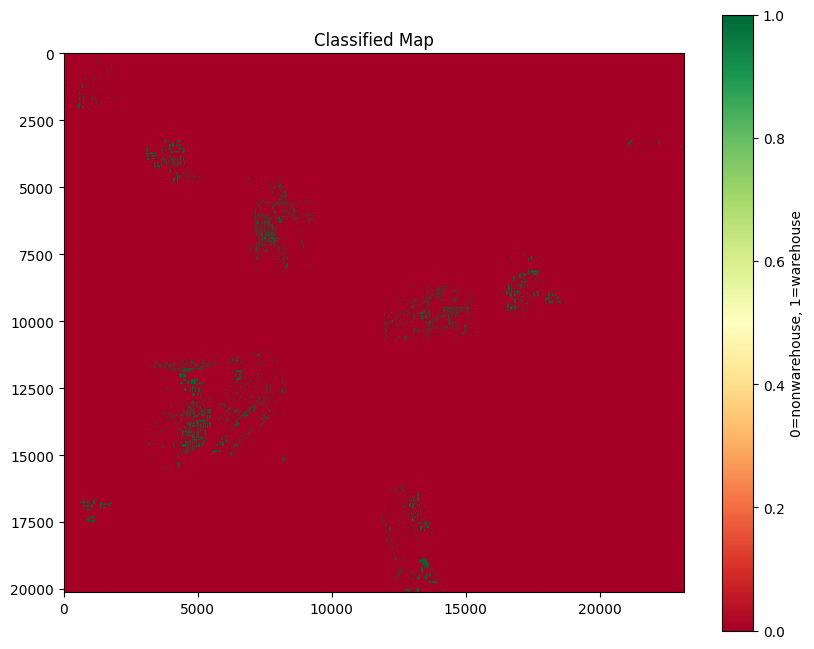

In [27]:
plt.figure(figsize=(10, 8))
plt.imshow(prediction_map, cmap='RdYlGn')
plt.colorbar(label='0=nonwarehouse, 1=warehouse')
plt.title('Classified Map')
plt.show()

## 9. Export to GeoTIFF

In [36]:
output_path = 'output_classification.tif'

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=n_rows,
    width=n_cols,
    count=1,
    dtype='uint8',
    crs=raster_crs,
    transform=raster_transform
) as dst:
    dst.write(prediction_map, 1)

print(f'Saved to {output_path}')

Saved to output_classification.tif
